# Kepler-51 planetary system in the light of the PhotoRing effect
## Reproducing the figures of Numpaque et al. (2026)

This notebook contains the code for reproducing the figures in the paper:

> S. Numpaque, J.I. Zuluaga, D. Kipping and J.A. Alvarado "Asterodensity profile analysis of the Kepler-51 planetary system:
a case study on the detection of exoplanetary rings via the PhotoRing effect", in preparation.

For detailed explanations see the GitHub repository: [https://github.com/seap-udea/PRisma](https://github.com/seap-udea/PRisma).

Generates the TTV-derived observable posteriors and the asterodensity-profiling
comparison used early in the manuscript:

- `figures/k51_observables_posteriors.png`
- `figures/rho_obs_comparison.png`


## Preparing the environment


In [1]:
# ── Bootstrap: make the repository packages importable without installation ──
import sys, pathlib
_HERE = pathlib.Path.cwd()
_cands = [_HERE, *_HERE.parents]
_REPO = next((c for c in _cands if (c / "pipeline" / "photoring").is_dir() and (c / "pipeline" / "exorings").is_dir()), _HERE.parent)
for _p in (str(_REPO / "pipeline"), str(_REPO)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root:", _REPO)


repo root: /Users/jzuluaga/dev/PRisma


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

import photoring as pr
import photoring.plotting as plot
from photoring import literature
from photoring.io import load_observables

# The manuscript's look: saturated palette, LaTeX, 95% corner intervals.
plot.apply_style(plot.PAPER_STYLE)

CASE = "kepler_51"
# This notebook does not live in pipeline/, so point CasePaths at it explicitly.
paths = pr.CasePaths(CASE, pipeline_dir=_REPO / "pipeline")
IMG = pathlib.Path(_REPO / "papers" / "kepler51" / "figures")
IMG.mkdir(parents=True, exist_ok=True)
print("writing figures to:", IMG)


writing figures to: /Users/jzuluaga/dev/PRisma/papers/kepler51/figures


In [3]:
from matplotlib.ticker import AutoMinorLocator
import photoring.literature as _lit_mod
import numpy as np
import matplotlib.pyplot as plt

def _annotate_stats(ax, v, symbol="", unit="", color="k", xpos="left", ypos=0.97,
                    offset=0.0, x=None, sep=" = ", fmt=".2f", draw_vlines=True,
                    vline_color=None, show_interval=True, va="top", fontsize=None):
    med, p16, p84 = np.percentile(v, [50, 16, 84])
    unit_str = f" {unit}" if unit else ""
    txt = (f"{symbol}{sep}{med:{fmt}}"
           f"$^{{+{p84 - med:{fmt}}}}_{{-{med - p16:{fmt}}}}${unit_str}")
    ha = "left" if xpos == "left" else "right"
    if x is None:
        x = 0.04 if xpos == "left" else 0.96
    else:
        lo, hi = ax.get_xlim()
        x = (x - lo) / (hi - lo)

    if draw_vlines:
        vc = vline_color or color
        plot._vline(ax, med, vc, lw=plot.STYLE["median_lw"], ls=plot.STYLE["median_ls"],
               alpha=plot.STYLE["median_alpha"], zorder=4)
        if show_interval:
            for q in (p16, p84):
                plot._vline(ax, q, vc, lw=plot.STYLE["sigma_lw"], ls=plot.STYLE["sigma_ls"],
                       alpha=plot.STYLE["sigma_alpha"], zorder=3)

    fs = fontsize if fontsize is not None else plot.STYLE["annot_size"] + 4
    ax.text(x, ypos + offset, txt, transform=ax.transAxes,
            fontsize=fs, color=color, ha=ha, va=va,
            fontfamily=plot.STYLE["font_family"])

## 1. Load TTV observables and the independent stellar density

These two figures are built entirely from the photometric / photodynamical
observables under `pipeline/kepler_51/inputs/` (plus the Berger+2023
$\rho_{\star,\rm true}$ samples). No nested-sampling chains are required.


In [4]:
PLANETS = ["b", "d"]

ttv = {pl: load_observables(paths.observables_file(pl)) for pl in PLANETS}
rho_true_samples = np.loadtxt(paths.rho_true_samples) / 1000.0   # kg/m^3 -> g/cm^3

print("TTV observables loaded:", {k: len(v["delta"]) for k, v in ttv.items()})
print("rho_true samples:", len(rho_true_samples),
      f"median={np.median(rho_true_samples):.3f} g/cm^3")


TTV observables loaded: {'b': 17756, 'd': 39002}
rho_true samples: 100000 median=1.896 g/cm^3


## 2. Transit observable posteriors

**Manuscript figure:** `k51_observables_posteriors.png`.

One row per planet, one column per observable. Filled distributions are this work's TTV
posteriors; vertical dashed lines and the accompanying labels give the median and 68%
credible interval. Unfilled curves are literature estimates built from published point values
and their reported uncertainties — a truncated normal for the impact parameter, whose physical
range is bounded. Only the observables a given source reports are drawn, which is why some
columns (notably $T_{23}$) carry no overlay.

Where the literature scatter exceeds the individual error bars, that is itself a result: for
the transit depth it points to unocculted stellar activity — Kepler-51 is young ($\sim$500 Myr)
and magnetically active, so an evolving spot distribution changes the out-of-transit flux and
inflates the measured depth if unmodelled. The impact parameter is the least constrained
observable, because Kepler's $\sim$30-minute cadence smears exactly the ingress/egress slopes
that carry the chord geometry. By contrast $a/R_\star$ is the most consistently determined,
being set almost entirely by the precisely measured period and total duration.


-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/k51_observables_posteriors.png


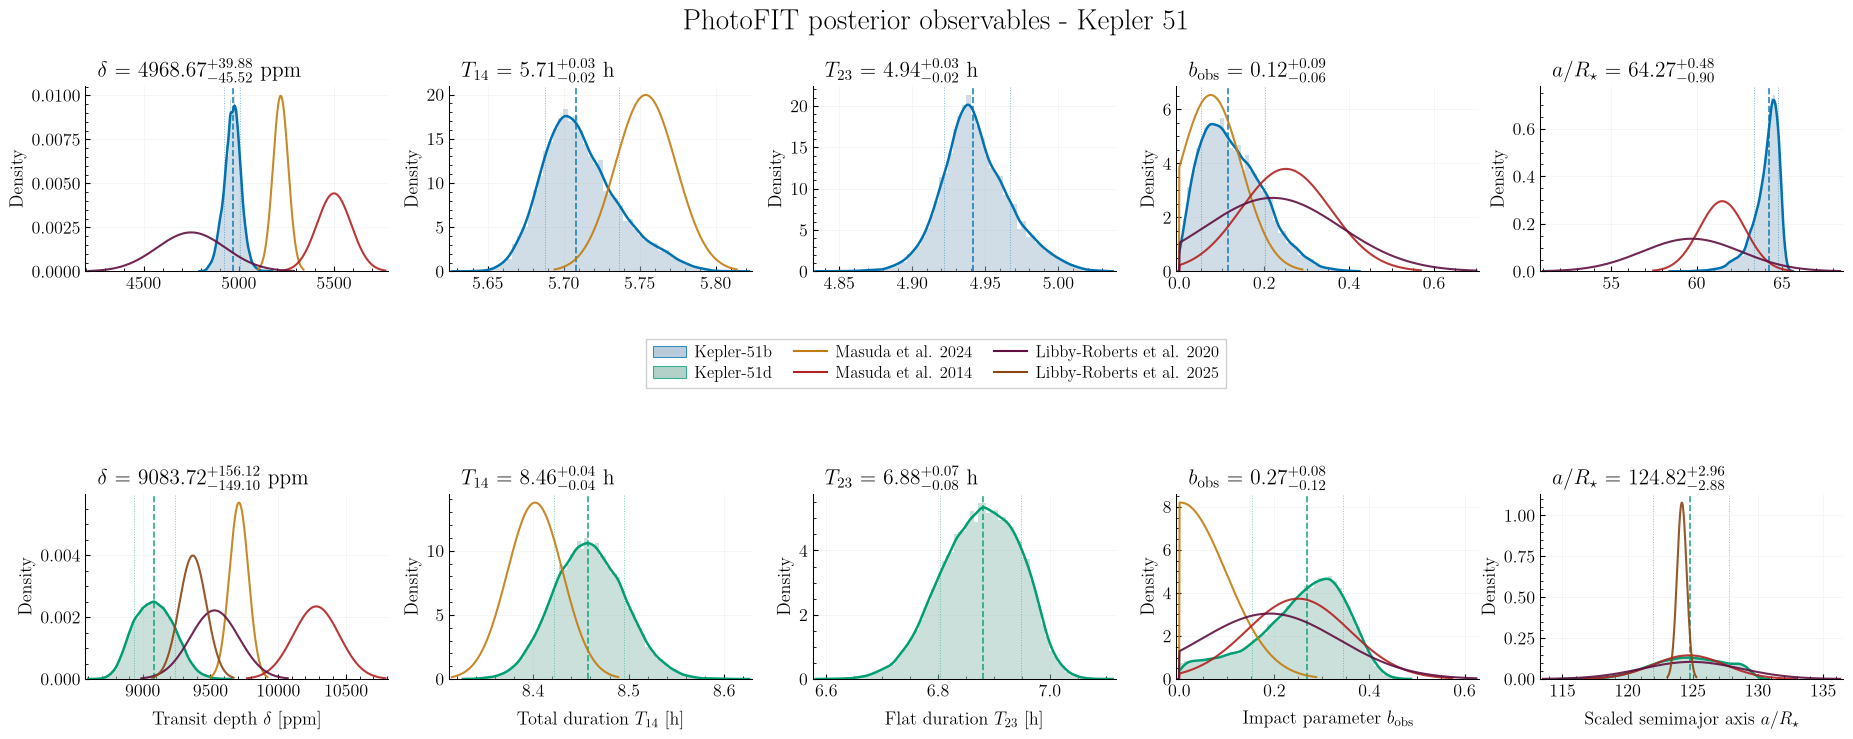

In [5]:
def plot_observable_posteriors(ttv_by_planet, keys=None, lit=None, paths=None,
                              run_tag="observables", title=None):
    keys = list(keys or ["delta", "T14", "T23", "b_obs", "aR"])
    planets = list(ttv_by_planet)
    lit = lit or {}
    nrows, ncols = len(planets), len(keys)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(plot.STYLE["fig_w_ppc"] * ncols * 1.08, plot.STYLE["fig_h_single"] * nrows * 1.1),
        gridspec_kw=dict(wspace=plot.STYLE["wspace"], hspace=plot.STYLE.get("hspace", 0.2) * 6),
        squeeze=False)

    sources_seen = []
    for row, planet in enumerate(planets):
        ttv = ttv_by_planet[planet]
        fill = plot.planet_color(planet, "fill")
        line = plot.planet_color(planet, "line")
        for col_i, key in enumerate(keys):
            ax = axes[row][col_i]
            meta = plot.obs_meta(key)
            v = np.asarray(ttv.get(meta["df_col"], []), dtype=float)
            v = v[np.isfinite(v)] * meta["scale"]
            if len(v) < 5:
                ax.set_axis_off()
                continue

            plot._hist1d(ax, v, fill, "", alpha=0.5, zorder=2)
            plot._kde_line(ax, v, line, label=plot.PLANET_LABELS.get(planet, planet),
                      lw=plot.STYLE["line_lw"])

            xmin, xmax = float(v.min()), float(v.max())
            for source, obs in lit.get(planet, {}).items():
                if key not in obs:
                    continue
                if source not in sources_seen:
                    sources_seen.append(source)
                lo, hi = plot._lit_curve(ax, key, obs[key], _lit_mod.color(source))
                xmin, xmax = min(xmin, lo), max(xmax, hi)
            if key == "b_obs":
                xmin = 0.0
            pad = 0.01 * (xmax - xmin)
            ax.set_xlim(xmin - pad, xmax + pad)

            _annotate_stats(ax, v, symbol=meta["symbol"], unit=meta["unit"],
                            color="k", vline_color=line, xpos="left", ypos=1.02,
                            va="bottom", fontsize=plot.STYLE["annot_size"] + 8)
            ax.set_ylabel("Density")
            if row == nrows - 1:
                ax.set_xlabel(meta["xlabel"], labelpad=8, fontsize=plot.STYLE["label_size"])
            ax.xaxis.set_minor_locator(AutoMinorLocator())
            ax.yaxis.set_minor_locator(AutoMinorLocator())

    #fig.supylabel("Probability Density", fontsize=plot.STYLE["label_size"] + 4, x=0.085)
    if title:
        fig.suptitle(title, fontsize=plot.STYLE["label_size"] + 8, y=0.98)

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    handles = [Patch(facecolor=plot.planet_color(p, "fill"),
                     edgecolor=plot.planet_color(p, "line"), lw=0.8, alpha=0.75,
                     label=plot.PLANET_LABELS.get(p, p)) for p in planets]
    handles += [Line2D([0], [0], color=_lit_mod.color(s), lw=plot.STYLE["lit_lw"],
                       ls=plot.STYLE["lit_ls"], label=s) for s in sources_seen]
    fig.legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 0.52),
               ncol=3, fontsize=plot.STYLE["legend_size"] * 1.5, framealpha=0.92,
               edgecolor="#cccccc", fancybox=False, handlelength=2.0,
               handletextpad=0.5, columnspacing=1.3, labelspacing=0.35)

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plot._save(fig, run_tag, paths, "observables")
    return fig


fig = plot_observable_posteriors(
    ttv,
    keys=["delta", "T14", "T23", "b_obs", "aR"],
    lit=literature.observables(CASE),
    title=f"PhotoFIT posterior observables - {CASE.replace('_', ' ').title()}",
)
fig.savefig(IMG / "k51_observables_posteriors.png", dpi=plot.STYLE["fig_dpi"],
            bbox_inches="tight")
print("->", IMG / "k51_observables_posteriors.png")
plt.show()


## 3. The stellar-density anomaly

**Manuscript figure:** `rho_obs_comparison.png`.

The pivotal measurement. Under the standard transit model — unblended, spot-free light curves,
spherical planets on circular orbits — *every* transiting planet of a system must yield the
same $\rho_{\star,\rm obs}$. So any disagreement between planets, or against an independent
determination of the star's density, means the standard model is failing to capture something
about the real transit geometry for at least one planet.

Filled distributions are the transit-derived densities for b and d; the filled reference
distribution is the isochrone-based posterior for the *true* stellar density; dotted curves
are independent literature determinations, drawn as two-sided Gaussians because they are
reported with asymmetric uncertainties.

Three explanations are possible: unmodelled starspots biasing $(a/R_\star)_{\rm obs}$, an
incomplete picture of the system's dynamics, or a ring system. The rest of the pipeline tests
the third — not as the preferred explanation, but to establish whether a ringed geometry can
reconcile the transit observables with a self-consistent stellar density.

Note the **sign**: the anomaly here is positive ($\rho_{\star,\rm obs} > \rho_{\star,\rm true}$),
the less common of the two PR regimes. That does not disfavour rings — physically valid
solutions span both — but it does confine them to a restricted part of orientation space.


-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/rho_obs_comparison.png


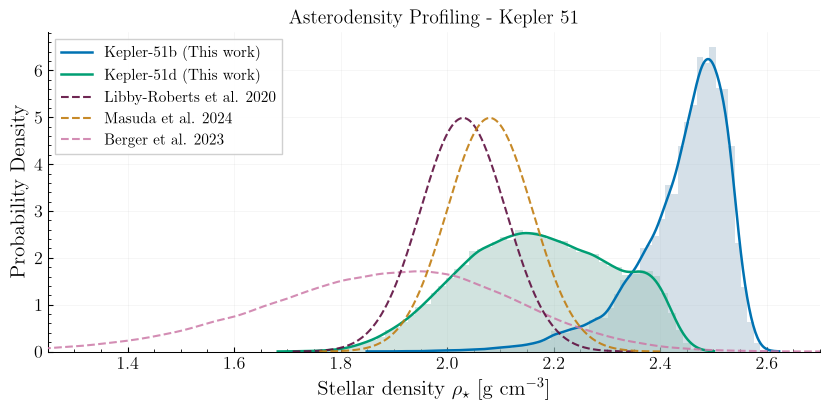

In [6]:
def plot_asterodensity_profiling(ttv_by_planet, rho_true_samples=None, lit_rho=None,
                                 paths=None, run_tag="rho_obs_comparison", title=None,
                                 annot_offsets=None, rho_true_label=None,
                                 legend_loc="upper left"):
    meta = plot.obs_meta("rho_obs")
    lit_rho = lit_rho or {}
    annot_offsets = annot_offsets or {}

    fig, ax = plt.subplots(figsize=(plot.STYLE["fig_w_ppc"] * 2.0, plot.STYLE["fig_h_single"] * 1.2))
    xs_lo, xs_hi = [], []

    for planet, ttv in ttv_by_planet.items():
        v = np.asarray(ttv.get(meta["df_col"], []), dtype=float)
        v = v[np.isfinite(v)] * meta["scale"]
        if len(v) < 5:
            continue
        fill = plot.planet_color(planet, "fill")
        line = plot.planet_color(planet, "line")
        label = plot.PLANET_LABELS.get(planet, planet)
        med, p16, p84 = np.percentile(v, [50, 16, 84])
        # label_text = f"{label} (This work): ${med:.2f}^{{+{p84-med:.2f}}}_{{-{med-p16:.2f}}}$ {meta['unit']}"
        label_text = f"{label} (This work)"
        plot._hist1d(ax, v, fill, "", alpha=0.45, zorder=2)
        plot._kde_line(ax, v, line, label=label_text, lw=plot.STYLE["line_lw"])
        xs_lo.append(v.min()); xs_hi.append(v.max())


    for source, entry in lit_rho.items():
        sm, sp = entry["sigma_minus"], entry["sigma_plus"]
        span = 4 * max(sm, sp)
        xg = np.linspace(entry["mu"] - span, entry["mu"] + span, 600)
        ax.plot(xg, plot.gauss_asym(xg, entry["mu"], sm, sp), color=_lit_mod.color(source),
                lw=plot.STYLE["lit_lw"], ls="--", alpha=plot.STYLE["lit_alpha"], zorder=6,
                label=source)
        xs_lo.append(xg.min()); xs_hi.append(xg.max())

    if rho_true_samples is not None and len(np.ravel(rho_true_samples)) > 5:
        rho_true = np.asarray(rho_true_samples, dtype=float).ravel()
        rho_true = rho_true[np.isfinite(rho_true)]
        c_ref = plot.STYLE.get("c_rho_true", plot.STYLE["c_prior"])
        #plot._hist1d(ax, rho_true, c_ref, "", alpha=0.20, zorder=1)
        plot._kde_line(ax, rho_true, c_ref,
                  label=rho_true_label or "Independent (isochrone)",
                  lw=plot.STYLE["lit_lw"], alpha=0.85, ls='--')
        xs_lo.append(rho_true.min()); xs_hi.append(rho_true.max())

    if xs_lo:
        lo, hi = min(xs_lo), max(xs_hi)
        pad = 0.05 * (hi - lo)
        ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(rf"Stellar density $\rho_{{\star}}$ [{meta['unit']}]",
                  fontsize=plot.STYLE["label_size"] + 2)
    ax.set_ylabel("Probability Density", fontsize=plot.STYLE["label_size"] + 2)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.legend(fontsize=plot.STYLE["legend_size"]*1.5 - 1, framealpha=0.92, edgecolor="#cccccc",
              fancybox=False, loc=legend_loc)
    ax.set_xlim(1.25,2.7)
    if title:
        ax.set_title(title, fontsize=plot.STYLE["label_size"] + 1)

    fig.tight_layout()
    plot._save(fig, run_tag, paths, "observables")
    return fig

fig = plot_asterodensity_profiling(
    ttv,
    rho_true_samples=rho_true_samples,
    # The independent (non-transit) determination the anomaly is measured against.
    rho_true_label="Berger et al. 2023",
    lit_rho=literature.rho_star(CASE),
    title="Asterodensity Profiling - Kepler 51",
    # Place each planet's label near its own median, clear of the legend and of each other.
    # (x_in_data, ypos, offset, xpos) per planet.
    annot_offsets={"b": (float(np.median(ttv["b"]["rho_obs_gcc"])) + 0.2, 0.98, 0.01, "right"),
                   "d": (float(np.median(ttv["d"]["rho_obs_gcc"])) + 0.03, 0.98, 0.0, "left")},
)
fig.savefig(IMG / "rho_obs_comparison.png", dpi=plot.STYLE["fig_dpi"], bbox_inches="tight")
print("->", IMG / "rho_obs_comparison.png")
plt.show()
